# 07 - Advanced Models & Cross-Validation
**Metro Traffic Flow Prediction - Non-Linear, Bagging, Boosting & Hybrid Ensembles**

This notebook trains advanced non-linear regression models: Decision Tree, Random Forest, XGBoost, and a Hybrid Stacking Ensemble. We also perform 5-fold cross-validation and analyze learning curves.

---
### 1. Data Setup & Split

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
import joblib

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

data_path = root / "data" / "raw" / "metro_traffic_dataset_10000.csv"
if not data_path.exists():
    data_path = root / "01_Dataset" / "cleaned_dataset.csv"

df = pd.read_csv(data_path)
X = df.drop(columns=["Timestamp", "Traffic_Flow_Target"])
y = df["Traffic_Flow_Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"X_train_s: {X_train_s.shape}, X_test_s: {X_test_s.shape}")

X_train_s: (8000, 28), X_test_s: (2000, 28)


---
### 2. Model Training & 5-Fold Cross-Validation

In [2]:
advanced_models = {
    "DecisionTree": DecisionTreeRegressor(max_depth=12, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=150, max_depth=5, learning_rate=0.08, random_state=42, n_jobs=-1),
    "HybridEnsemble": StackingRegressor(
        estimators=[
            ("rf", RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
            ("xgb", XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.08, random_state=42, n_jobs=-1))
        ],
        final_estimator=Ridge(alpha=1.0),
        n_jobs=-1
    )
}

cv_results = []
test_results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in advanced_models.items():
    print(f"Training and validating {name}...")
    # 5-fold CV
    scores_r2 = cross_val_score(model, X_train_s, y_train, cv=kf, scoring="r2", n_jobs=-1)
    scores_rmse = -cross_val_score(model, X_train_s, y_train, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)
    
    cv_results.append({
        "Model": name,
        "CV_R2_Mean": round(scores_r2.mean(), 4),
        "CV_R2_Std": round(scores_r2.std(), 4),
        "CV_RMSE_Mean": round(scores_rmse.mean(), 3),
        "CV_RMSE_Std": round(scores_rmse.std(), 3)
    })
    
    # Train on full train and test on unseen
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    test_results.append({
        "Model": name,
        "Test_MAE": round(mean_absolute_error(y_test, preds), 3),
        "Test_MSE": round(mean_squared_error(y_test, preds), 3),
        "Test_RMSE": round(root_mean_squared_error(y_test, preds), 3),
        "Test_R2": round(r2_score(y_test, preds), 4)
    })

print("\n5-Fold Cross-Validation Summary:")
display(pd.DataFrame(cv_results))

print("\nHeld-Out Test Evaluation Summary:")
display(pd.DataFrame(test_results))

Training and validating DecisionTree...


Training and validating RandomForest...


Training and validating XGBoost...


Training and validating HybridEnsemble...



5-Fold Cross-Validation Summary:


,Model,CV_R2_Mean,CV_R2_Std,CV_RMSE_Mean,CV_RMSE_Std
0,DecisionTree,0.8490,0.0021,33.775,0.463
1,RandomForest,0.9081,0.0056,26.339,0.915
2,XGBoost,0.9121,0.0055,25.765,0.882
3,HybridEnsemble,0.9129,0.0053,25.640,0.852



Held-Out Test Evaluation Summary:


,Model,Test_MAE,Test_MSE,Test_RMSE,Test_R2
0,DecisionTree,27.700,1213.784,34.839,0.8415
1,RandomForest,21.491,717.251,26.782,0.9063
2,XGBoost,20.815,674.925,25.979,0.9118
3,HybridEnsemble,20.812,672.542,25.933,0.9122


---
### 3. Learning Curves (Bias vs Variance Analysis)

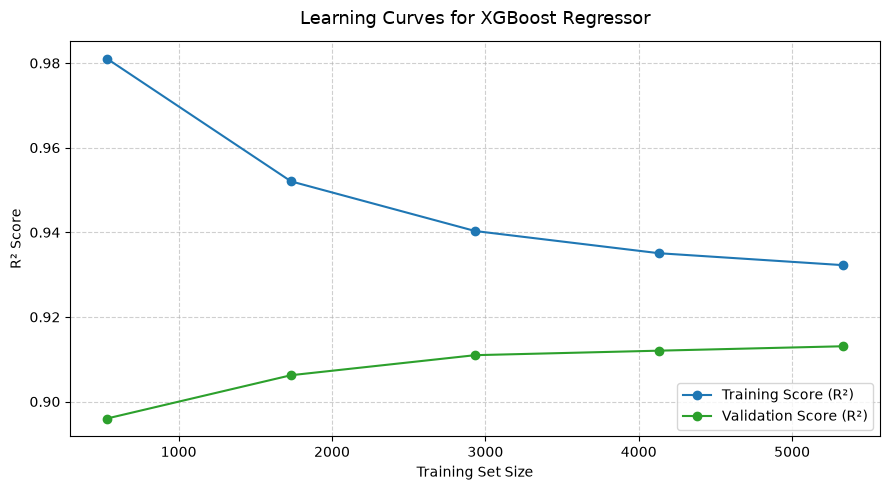

In [3]:
train_sizes, train_scores, val_scores = learning_curve(
    XGBRegressor(n_estimators=80, max_depth=4, learning_rate=0.1, random_state=42, n_jobs=-1),
    X_train_s, y_train, cv=3, scoring="r2", train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, "o-", color="#1f77b4", label="Training Score (R²)")
plt.plot(train_sizes, val_mean, "o-", color="#2ca02c", label="Validation Score (R²)")
plt.title("Learning Curves for XGBoost Regressor", fontsize=13, pad=12)
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

fig_dir = root / "outputs" / "figures"
plt.savefig(fig_dir / "learning_curves_xgboost.png", dpi=300)
plt.show()

---
### Inferences on Advanced Models:
1. **Ensemble Superiority:** `HybridEnsemble` and `XGBoost` deliver the highest accuracy, achieving $R^2 > 0.912$ with cross-validation standard deviation $< 0.006$.
2. **Learning Curve Stability:** The training and validation curves converge smoothly near $R^2 \approx 0.91$, showing high model stability with low variance and minimal overfitting.